In [132]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset
import torch.nn.functional as F
import time 
import numpy as np
import matplotlib.pyplot as plt

In [133]:
# 查看可用GPU数量
print(f"可用GPU数量: {torch.cuda.device_count()}")

# 遍历所有GPU，查看显存状态
for i in range(torch.cuda.device_count()):
    total_mem = torch.cuda.get_device_properties(i).total_memory / (1024**3)  # 转GiB
    free_mem = torch.cuda.memory_allocated(i) / (1024**3)  # 已分配显存
    available_mem = total_mem - free_mem  # 可用显存
    print(f"GPU {i}: 总显存={total_mem:.2f}GiB, 已用={free_mem:.2f}GiB, 可用={available_mem:.2f}GiB")

可用GPU数量: 1
GPU 0: 总显存=8.00GiB, 已用=1.15GiB, 可用=6.85GiB


In [134]:
print(torch.cuda.memory_summary())

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |   1174 MiB |   1431 MiB |  97887 GiB |  97886 GiB |
|       from large pool |    982 MiB |   1195 MiB |  54891 GiB |  54890 GiB |
|       from small pool |    192 MiB |    236 MiB |  42996 GiB |  42996 GiB |
|---------------------------------------------------------------------------|
| Active memory         |   1174 MiB |   1431 MiB |  97887 GiB |  97886 GiB |
|       from large pool |    982 MiB |   1195 MiB |  54891 GiB |

In [135]:
import scipy
data = scipy.io.loadmat('real2d.mat')
Dn=data['Dn']


In [136]:
def calculate_snr(clean_data, denoised_data):
    # 确保输入是一维向量，或者直接不带 ord 参数（默认就是 Frobenius 范数，即全图能量）
    norm_clean = np.linalg.norm(clean_data)  # 默认计算所有元素的平方和开根号
    norm_diff = np.linalg.norm(clean_data - denoised_data)
    
    snr = 20 * np.log10(norm_clean / norm_diff)
    return snr

In [137]:
def patch2d(A,l1=8,l2=8,s1=4,s2=4,mode=1):
	"""
	patch2d: decompose the image into patches:
	
	INPUT
	D: input image
	l1: first patch size
	l2: second patch size
	s1: first shifting size
	s2: second shifting size
	mode: patching mode
	
	OUTPUT
	X: patches
	
	HISTORY
	by Yangkang Chen
	Oct, 2017
	Modified on Dec 12, 2018 (the edge issue, arbitrary size for the matrix)
			 Dec 31, 2018 (tmp1=mod(n1,l1) -> tmp1=mod(n1-l1,s1))
	
	EXAMPLE 1
	
	#generate data
	from pyseistr import gensyn
	data,noisy=gensyn(noise=True);[n1,n2]=data.shape;
	import matplotlib.pyplot as plt;
	plt.subplot(1,2,1);plt.imshow(data,clim=[-0.2,0.2],aspect='auto');plt.xlabel('Trace');plt.ylabel('Time sample');
	plt.subplot(1,2,2);plt.imshow(noisy,clim=[-0.2,0.2],aspect='auto');plt.xlabel('Trace');
	plt.show();
	
	from pyseistr import patch2d
	X=patch2d(data,l1=16,l2=16,s1=8,s2=8);

	#visualize the patches
	from pyseistr import cseis
	plt.imshow(X,aspect='auto',cmap=cseis());plt.ylabel('Patch NO');plt.xlabel('Patch Pixel');plt.show()
	plt.figure(figsize=(8,8))
	for ii in range(64):
		ax=plt.subplot(8,8,ii+1)
		plt.imshow(X[3200+ii,:].reshape(16,16,order='F'),cmap=cseis(),clim=(-0.5,0.5),aspect='auto');
		plt.setp(ax.get_xticklabels(), visible=False);plt.setp(ax.get_yticklabels(), visible=False);
	plt.show()

	#reconstruct
	from pyseistr import patch2d_inv
	import numpy as np
	data2=patch2d_inv(X,n1,n2,l1=16,l2=16,s1=8,s2=8);
	print('Error=',np.linalg.norm(data.flatten()-data2.flatten()))
	
	plt.figure(figsize=(16,8));
	plt.imshow(np.concatenate([data,data2,data-data2],axis=1),aspect='auto');
	plt.show()

	EXAMPLE 2
	https://github.com/chenyk1990/mlnb/blob/main/DL_denoise_simple2D.ipynb
	
	EXAMPLE 3
	sgk_denoise() in pyseisdl/denoise.py
	"""
	[n1,n2]=A.shape;

	if mode==1: 	#possible for other patching options
		
		tmp=np.mod(n1-l1,s1);
		if tmp!=0:
			A=np.concatenate((A,np.zeros([s1-tmp,n2])),axis=0); 
		tmp=np.mod(n2-l2,s2);
		if tmp!=0:
			A=np.concatenate((A,np.zeros([A.shape[0],s2-tmp])),axis=1); 
		
		[N1,N2]=A.shape;
		X=[]
		for i1 in range(0,N1-l1+1,s1):
			for i2 in range(0,N2-l2+1,s2):
						tmp=np.reshape(A[i1:i1+l1,i2:i2+l2],(l1*l2,1),order='F');
						X.append(tmp)
		X = np.array(X)
	else:
		#not written yet
		pass;
	return X[:,:,0]



def patch2d_inv(X,n1,n2,l1=8,l2=8,s1=4,s2=4,mode=1):
	"""
	patch2d_inv: insert patches into the image
	
	INPUT
	D: input patches (sample,patchsize)
	mode: patching mode
	l1: first patch size
	l2: second patch size
	s1: first shifting size
	s2: second shifting size
	
	OUTPUT
	X: patches
	
	HISTORY
	by Yangkang Chen
	Oct, 2017
	Modified on Dec 12, 2018 (the edge issue, arbitrary size for the matrix)
				Dec 31, 2018 (tmp1=mod(n1,l1) -> tmp1=mod(n1-l1,s1))
	
	EXAMPLE 1
	
	#generate data
	from pyseistr import gensyn
	data,noisy=gensyn(noise=True);[n1,n2]=data.shape;
	import matplotlib.pyplot as plt;
	plt.subplot(1,2,1);plt.imshow(data,clim=[-0.2,0.2],aspect='auto');plt.xlabel('Trace');plt.ylabel('Time sample');
	plt.subplot(1,2,2);plt.imshow(noisy,clim=[-0.2,0.2],aspect='auto');plt.xlabel('Trace');
	plt.show();
	
	from pyseistr import patch2d
	X=patch2d(data,l1=16,l2=16,s1=8,s2=8);

	#visualize the patches
	from pyseistr import cseis
	plt.imshow(X,aspect='auto',cmap=cseis());plt.ylabel('Patch NO');plt.xlabel('Patch Pixel');plt.show()
	plt.figure(figsize=(8,8))
	for ii in range(64):
		ax=plt.subplot(8,8,ii+1)
		plt.imshow(X[3200+ii,:].reshape(16,16,order='F'),cmap=cseis(),clim=(-0.5,0.5),aspect='auto');
		plt.setp(ax.get_xticklabels(), visible=False);plt.setp(ax.get_yticklabels(), visible=False);
	plt.show()

	#reconstruct
	from pyseistr import patch2d_inv
	import numpy as np
	data2=patch2d_inv(X,n1,n2,l1=16,l2=16,s1=8,s2=8);
	print('Error=',np.linalg.norm(data.flatten()-data2.flatten()))
	
	plt.figure(figsize=(16,8));
	plt.imshow(np.concatenate([data,data2,data-data2],axis=1),aspect='auto');
	plt.show()

	EXAMPLE 2
	https://github.com/chenyk1990/mlnb/blob/main/DL_denoise_simple3D.ipynb
	
	EXAMPLE 3
	sgk_denoise() in pyseisdl/denoise.py

	"""

	if mode==1: 	#possible for other patching options

		tmp1=np.mod(n1-l1,s1);
		tmp2=np.mod(n2-l2,s2);
		if tmp1!=0 and tmp2!=0:
			A=np.zeros([n1+s1-tmp1,n2+s2-tmp2]); 
			mask=np.zeros([n1+s1-tmp1,n2+s2-tmp2]); 

		if tmp1!=0 and tmp2==0:
			A=np.zeros([n1+s1-tmp1,n2]); 
			mask=np.zeros([n1+s1-tmp1,n2]);

		if tmp1==0 and tmp2!=0:
			A=np.zeros([n1,n2+s2-tmp2]);   
			mask=np.zeros([n1,n2+s2-tmp2]);   


		if tmp1==0 and tmp2==0:
			A=np.zeros([n1,n2]); 
			mask=np.zeros([n1,n2]);

		[N1,N2]=A.shape;
		id=-1;
		for i1 in range(0,N1-l1+1,s1):
			for i2 in range(0,N2-l2+1,s2):
				id=id+1;
				A[i1:i1+l1,i2:i2+l2]=A[i1:i1+l1,i2:i2+l2]+np.reshape(X[id,:],[l1,l2],order='F');
				mask[i1:i1+l1,i2:i2+l2]=mask[i1:i1+l1,i2:i2+l2]+np.ones([l1,l2]);

		A=A/mask; 
		A=A[0:n1,0:n2];
	else:
		#not written yet
		pass;
	return A

In [138]:
import scipy
w1=48
w2=48
s1=1
s2=1
X=patch2d(Dn,w1,w2,s1,s2)

[nz,nx]=Dn.shape
X.shape
print(X.dtype)
X = X.astype(np.float32)
Pdata = torch.from_numpy(X)
print(Pdata.dtype)

float64
torch.float32


In [139]:
# 数据分割：80% 训练数据，20% 验证数据
train_size = int(len(Pdata) * 0.8)
train = Pdata[:train_size]
valid = Pdata[train_size:]

# 打印训练集和验证集的形状
print(f"Train shape: {train.shape}")
print(f"Valid shape: {valid.shape}")
#创建 TensorDataset
train_data = TensorDataset(train)
valid_data = TensorDataset(valid)

# 设置 batch_size
batch_size1 = 64


# 创建 DataLoader
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size1, shuffle=True)
valid_loader = torch.utils.data.DataLoader(valid_data, batch_size=batch_size1, shuffle=True)

Train shape: torch.Size([28272, 2304])
Valid shape: torch.Size([7068, 2304])


In [140]:
train.shape
valid.shape
print(valid.dtype)

torch.float32


In [ ]:
class SDD(nn.Module):
    def __init__(self, drop_prob=0.0):
        super(SDD, self).__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        # 如果设定概率为0或处于验证/测试模式，直接原样输出
        if self.drop_prob == 0. or not self.training:
            return x
            
        # 【关键修改】：放弃整条路径清零，改用特征元素级 Dropout。
        # 既保证了主信号不断崖式消失，又严格执行了随深度递增的丢弃概率 (drop_prob)
        return F.dropout(x, p=self.drop_prob, training=self.training)
        if self.print_counter < 2:
            # 计算当前 batch 里面，实际为 0 (被丢弃) 的样本比例
            actual_drop_rate = 1.0 - random_tensor.mean().item()
            print(f"[SDD 运行监控] 理论丢弃率: {self.drop_prob:.4f} | 当前Batch实际丢弃比例: {actual_drop_rate:.4f}")
            self.print_counter += 1

        return x.div(keep_prob) * random_tensor

In [141]:
class FCB(nn.Module):
    def __init__(self, input_size, output_size, dropout=0.0):
        super().__init__()
        self.fc = nn.Linear(input_size, output_size)
        self.activation = nn.LeakyReLU()
        self.bn = nn.BatchNorm1d(output_size)
        self.sdd = SDD(drop_prob=dropout)  # 严格对应论文公式

    def forward(self, x):
        x = self.fc(x)
        x = self.activation(x) 
        x = self.bn(x)
        x = self.sdd(x)  # 应用随机深度丢弃
        return x

In [142]:
class SAB(nn.Module):  ## Self-Attention Block
    def __init__(self, input_size, output_size, dropout=0.1):
        super().__init__()
        self.fcb1 = FCB(input_size, output_size, dropout)  # Query
        self.fcb2 = FCB(input_size, output_size, dropout)  # Key
        self.fcb3 = FCB(input_size, output_size, dropout)  # Value
        self.fcb4 = FCB(input_size, output_size, dropout)  # Residual
        self.bn = nn.BatchNorm1d(output_size)
        self.softmax = nn.Softmax(dim=-1)
        self.adjust_dim = nn.Linear(input_size, output_size)  # 调整维度

    def forward(self, x):
        query = self.fcb1(x)
        key = self.fcb2(x)
        value = self.fcb3(x)
        residual = self.fcb4(x)

        # 自注意力机制  
        attention_scores = torch.matmul(query, key.transpose(-1, -2))  # Q * K^T
        attention_scores = self.softmax(attention_scores)  # 对注意力分数应用 Softmax
        weighted_sum = torch.matmul(attention_scores, value)  # 加权求和
        weighted_sum = self.bn(weighted_sum)  # 对加权求和的结果应用批归一化

        # 残差连接
        if residual.size(1) != weighted_sum.size(1):
            residual = self.adjust_dim(residual)  # 调整维度
        output = weighted_sum + residual  # 残差连接

        return output

In [143]:
class MHB(nn.Module):  ##multi head block
    def __init__(self, input_size, output_size, dropout=0.1):
        super().__init__()
        self.sab1 = SAB(input_size, output_size, dropout)
        self.sab2 = SAB(input_size, output_size, dropout)
        self.sab3 = SAB(input_size, output_size, dropout)
        
        # 使用更合适的卷积参数
        self.cov1d = nn.Conv1d(in_channels=3, out_channels=1, kernel_size=1, stride=1, padding=0)
        
        # 或者使用线性层代替卷积
        self.fusion = nn.Linear(3 * output_size, output_size)

    def forward(self, x):
        x1 = self.sab1(x)  # [batch_size, seq_len, hidden_size]
        x2 = self.sab2(x)
        x3 = self.sab3(x)
        
        # 方法1: 使用线性层融合（推荐）
        x_cat = torch.cat([x1, x2, x3], dim=-1)  # [batch_size, seq_len, 3*hidden_size]
        x = self.fusion(x_cat)  # [batch_size, seq_len, hidden_size]
        
        return x
        
        # 方法2: 使用卷积（如果必须使用）
        # x1 = x1.transpose(1, 2).unsqueeze(1)  # [batch_size, 1, hidden_size, seq_len]
        # x2 = x2.transpose(1, 2).unsqueeze(1)
        # x3 = x3.transpose(1, 2).unsqueeze(1)
        # x = torch.cat([x1, x2, x3], dim=1)  # [batch_size, 3, hidden_size, seq_len]
        # x = x.reshape(x.shape[0], 3, -1)  # [batch_size, 3, hidden_size*seq_len]
        # x = self.cov1d(x)  # [batch_size, 1, hidden_size*seq_len]
        # x = x.reshape(x.shape[0], -1, x1.shape[3])  # [batch_size, hidden_size, seq_len]
        # x = x.transpose(1, 2)  # [batch_size, seq_len, hidden_size]
        # return x

In [144]:
class TSB(nn.Module):
    def __init__(self, input_size, output_size, dropout=0.0):
        super().__init__()   
        self.mhb1 = MHB(input_size, output_size, dropout)
        self.mhb2 = MHB(output_size, output_size, dropout)
        self.fc1 = nn.Linear(output_size, output_size)
        self.fc2 = nn.Linear(output_size, output_size)
        
    def forward(self, x):
        x1 = self.mhb1(x)
        x2 = self.fc1(x1)
        x3 = x2 + x1
        x4 = self.mhb2(x3)
        x5 = self.fc2(x4)
        x6 = x5 + x4
        return x6

In [145]:
class EnCoder(nn.Module):
    def __init__(self, input_size, p_max=0.2, L=6):
        super().__init__()
        self.adjust_dim = nn.Linear(input_size, 1024)
        
        # ====================================================
        # 引入自然对数型 Log-SDD 概率分配 (凹曲线)
        # ====================================================
        k = 10.0  # 曲率控制系数。k 越大，浅层起步的丢弃率飙升得越猛
        denom = math.log(1.0 + k)
        
        p1 = (math.log(1.0 + k * 1 / L) / denom) * p_max
        p2 = (math.log(1.0 + k * 2 / L) / denom) * p_max
        p3 = (math.log(1.0 + k * 3 / L) / denom) * p_max
        p4 = (math.log(1.0 + k * 4 / L) / denom) * p_max
        p5 = (math.log(1.0 + k * 5 / L) / denom) * p_max
        p6 = (math.log(1.0 + k * 6 / L) / denom) * p_max

        # 打印各层的 Log-SDD 设定概率
        print("\n" + "="*45)
        print("[EnCoder] 自然对数型 Log-SDD 丢弃概率分配表:")
        print(f"浅层 L1 (TSB)  p_1 = {p1:.4f}")
        print(f"中层 L2 (MHB)  p_2 = {p2:.4f}")
        print(f"中层 L3 (SAB)  p_3 = {p3:.4f}")
        print(f"深层 L4 (FCB1) p_4 = {p4:.4f}")
        print(f"深层 L5 (FCB2) p_5 = {p5:.4f}")
        print(f"最深 L6 (FCB3) p_6 = {p6:.4f}")
        print("="*45 + "\n")

        # 实例化各层
        self.tsb = TSB(1024, 512, dropout=p1)   
        self.mhb = MHB(512, 256, dropout=p2)
        self.sab = SAB(256, 128, dropout=p3)
        self.fcb1 = FCB(128, 32, dropout=p4)
        self.fcb2 = FCB(32, 8, dropout=p5)  
        self.fcb3 = FCB(8, 4, dropout=p6)
        
    def forward(self, x):
        x = self.adjust_dim(x) 
        x1 = self.tsb(x)
        x2 = self.mhb(x1)
        x3 = self.sab(x2)
        x4 = self.fcb1(x3)
        x5 = self.fcb2(x4)  
        x6 = self.fcb3(x5)
        return x1, x2, x3, x4, x5, x6

In [146]:
class DeCoder(nn.Module):
    def __init__(self, output_size, p_max=0.2, L=6):
        super().__init__()
        
        # ====================================================
        # 引入自然对数型 Log-SDD 概率分配 (凹曲线)
        # ====================================================
        k = 10.0  # 必须与 EnCoder 保持一致的曲率控制系数
        denom = math.log(1.0 + k)
        
        # 概率计算与 EnCoder 完全相同
        p1 = (math.log(1.0 + k * 1 / L) / denom) * p_max
        p2 = (math.log(1.0 + k * 2 / L) / denom) * p_max
        p3 = (math.log(1.0 + k * 3 / L) / denom) * p_max
        p4 = (math.log(1.0 + k * 4 / L) / denom) * p_max
        p5 = (math.log(1.0 + k * 5 / L) / denom) * p_max
        p6 = (math.log(1.0 + k * 6 / L) / denom) * p_max

        # 解码器从深到浅，丢弃率从最大(p6)逐渐减小到最小(p1)，维持对称正则化
        self.fcb1 = FCB(4, 8, dropout=p6)       # 最深层，丢弃率最大
        self.fcb2 = FCB(16, 32, dropout=p5)
        self.fcb3 = FCB(64, 128, dropout=p4)
        self.sab = SAB(256, 256, dropout=p3)
        self.mhb = MHB(512, 512, dropout=p2)
        self.tsb = TSB(1024, 1024, dropout=p1)  # 最浅层，丢弃率最小
        self.adjust_dim = nn.Linear(1024, output_size) 

    def forward(self, x1, x2, x3, x4, x5, x6):
        y6  = self.fcb1(x6)
        y51 = torch.cat((y6, x5), dim=1)
        y5  = self.fcb2(y51)
        y41 = torch.cat((y5, x4), dim=1)
        y4  = self.fcb3(y41)
        y31 = torch.cat((y4, x3), dim=1)
        y3  = self.sab(y31)
        y21 = torch.cat((y3, x2), dim=1)
        y2  = self.mhb(y21)
        y11 = torch.cat((y2, x1), dim=1)
        y0  = self.tsb(y11)
        y = self.adjust_dim(y0) 
        return y

In [147]:
class AutoCoder(nn.Module):
    # 新增：让 AutoCoder 也接收 p_max 和 L，并设置默认值为您的甜点区参数
    def __init__(self, input_size, output_size, p_max=0.2, L=6):
        super().__init__()

        # 将 p_max 和 L 传递给底层的 EnCoder 和 DeCoder
        self.encoder = EnCoder(input_size, p_max=p_max, L=L)
        self.decoder = DeCoder(output_size, p_max=p_max, L=L)

    def forward(self, x):
        x1, x2, x3, x4, x5, x6 = self.encoder(x)
        x = self.decoder(x1, x2, x3, x4, x5, x6)
        return x

In [148]:
class HuberLoss(nn.Module):
    def __init__(self, delta=1.0, reduction='mean'):
        """
        Huber损失函数
        
        Args:
            delta: 阈值参数，控制从L2损失切换到L1损失的边界
            reduction: 损失归约方式，'mean' | 'sum' | 'none'
        """
        super(HuberLoss, self).__init__()
        self.delta = delta
        self.reduction = reduction
    
    def forward(self, input, target):
        """
        Args:
            input: 预测值
            target: 真实值
        """
        diff = torch.abs(input - target)
        condition = diff < self.delta
        
        # 当差值小于delta时使用L2损失，否则使用L1损失
        loss = torch.where(condition, 
                          0.5 * diff ** 2, 
                          self.delta * (diff - 0.5 * self.delta))
        
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

In [149]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class HuberTVLoss(nn.Module):
    def __init__(self, huber_delta=1.0, tv_weight=1e-3, huber_weight=1.0, w1=32, w2=32):
        super(HuberTVLoss, self).__init__()
        self.huber_delta = huber_delta      # Huber Loss的阈值δ
        self.tv_weight = tv_weight          # TV Loss的权重β
        self.huber_weight = huber_weight    # Huber Loss的权重α
        self.w1 = w1                        # Patch的时间轴长度
        self.w2 = w2                        # Patch的道轴长度

    def huber_loss(self, y_pred, y_true):
        """Huber Loss实现"""
        residual = y_true - y_pred
        abs_residual = torch.abs(residual)
        quadratic = torch.clamp(abs_residual, max=self.huber_delta)
        linear = abs_residual - quadratic
        return 0.5 * quadratic.pow(2) + self.huber_delta * linear

    def tv_loss_torch(self, u):
        dt = u[1:, :] - u[ :-1, :]
        dx = u[ :, 1:] - u[ :, :-1]
        return dt.abs().mean() + dx.abs().mean()

    def forward(self, y_pred, y_true):
        """
        Args:
            y_pred: 模型输出 (Tensor, [B, N] 向量或 [B, C, H, W] 图像)
            y_true: 真实标签 (Tensor, 形状与y_pred相同)
        """
        # 1. 计算Huber Loss (基础重构误差)
        huber = self.huber_loss(y_pred, y_true).mean()

        # 2. 动态 Reshape 以启用 TV Loss 计算
        # 判断是否需要根据 w1, w2 进行还原
        if y_pred.dim() != 4:
            # 针对向量输入 [B, N]，还原为 [B, 1, H, W]
            # 根据您提供的 patch2d_inv (order='F')，先还原为 (w2, w1) 再转置
            y_gen = y_pred.view(-1, 1, self.w2, self.w1).permute(0, 1, 3, 2)
        else:
            y_gen = y_pred

        # 3. 计算 TV Loss 
        # (已按确认需求：移除Softmax约束，直接在振幅上计算)
        B, C, H, W = y_gen.shape
        
        # 地震数据二维梯度计算
        dt = y_gen[:, :, 1:, :] - y_gen[:, :, :-1, :] # 时间向梯度
        dx = y_gen[:, :, :, 1:] - y_gen[:, :, :, :-1] # 空间向梯度
        tv = dt.abs().mean() + dx.abs().mean()

        # 4. 监控打印 (仅在第一次调用时显示)
        if not hasattr(self, 'printed_once'):
            print("\n" + "="*50)
            print(f"[HuberTVLoss 监控] (🌟 动态尺寸: {self.w1}x{self.w2})")
            print(f"-> 输入形状: {y_pred.shape} -> TV计算形状: {y_gen.shape}")
            print(f"-> 原始值: Huber={huber.item():.6f}, TV={tv.item():.8f}")
            print(f"-> 加权后: Huber_W={self.huber_weight * huber.item():.6f}, TV_W={self.tv_weight * tv.item():.8f}")
            print(f"-> Total Loss: {self.huber_weight * huber.item() + self.tv_weight * tv.item():.6f}")
            print("="*50 + "\n")
            self.printed_once = True

        # 5. 联合损失汇总
        total_loss = self.huber_weight * huber + self.tv_weight * tv
        
        return total_loss

In [150]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 初始化模型并移动到设备
#model = Coder(w1 * w2, w1 * w2).to(device)
model = AutoCoder(input_size=w1 * w2,output_size=w1 * w2,p_max=0.20, L=6).to(device)
# 初始化损失函数
#criterion = Loss0(delta=0.36,r=0.5)
#criterion = L2TVLoss(l2_weight=0.3, tv_weight=0.7)
#criterion =TukeysBiweightLoss(c=9)
#criterion =TanhLoss()

#criterion = HuberTVLoss(huber_delta=1.5, tv_weight=0.0075, huber_weight=0.8)
#criterion = HuberTVLoss(w1=w1, w2=w2, huber_delta=1.5, tv_weight=0.005, huber_weight=0.9)
criterion = HuberTVLoss( huber_delta=1.5, tv_weight=0.00050, huber_weight=0.90)

#criterion = HuberLoss(delta=0.75)

# 初始化优化器
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

Using device: cuda


In [151]:
import time
import torch
import numpy as np

# 假设你已定义好 model/optimizer/criterion/train_loader/valid_loader/device/batch_size1 等变量
# （如果未定义，需补充这些基础变量）

start_time = time.time()
es_cnt = 0
es_thres = 5
prev_valid_loss = float('inf')
loss_train = []
loss_valid = []
num_epochs = 50  # 总训练轮数

for epoch in range(num_epochs):
    # 训练
    model.train()
    train_loss = 0.0
    for i, (batch) in enumerate(train_loader):
        # 数据转到 device
        train_batch = batch[0].to(device)
        
        # 👇 新增：打印最初处理的向量/张量维度（仅epoch=0, i=0时打印一次）
        if epoch == 0 and i == 0:
            print("\n========== 数据维度 & 数值范围 摸底 ==========")
            # 1. 打印原始输入批次的维度
            print(f"【输入数据维度】train_batch.shape: {train_batch.shape}")
            print(f"  - 批次大小（第0维）: {train_batch.shape[0]}")
            print(f"  - 通道数（第1维）: {train_batch.shape[1] if len(train_batch.shape)>=2 else '无'}")
            print(f"  - 高度（第2维）: {train_batch.shape[2] if len(train_batch.shape)>=3 else '无'}")
            print(f"  - 宽度（第3维）: {train_batch.shape[3] if len(train_batch.shape)>=4 else '无'}")
            
            # 2. 打印数值范围（保留你原来的max/min）
            print(f"\n【输入数据数值范围】")
            print(f"  - 最大值: {train_batch.max().item():.6f}")
            print(f"  - 最小值: {train_batch.min().item():.6f}")
            print(f"  - 平均值: {train_batch.mean().item():.6f}")
            print("==============================================\n")

        if epoch == 0 and i == 0:
            print("\n========== 真正的数据分布揭秘 ==========")
        # 抛弃极端的 1% 噪声，看剩下 99% 数据（通常是真实信号）的绝对振幅有多大
            q99 = torch.quantile(train_batch.abs(), 0.99).item()
            print("99% 的数据绝对值都在这个数值以下:", q99)
            print("数据的标准差 (均值附近的波动范围):", train_batch.std().item())
            print("======================================\n")
        # 👆 维度打印结束
        
        # 训练步骤
        optimizer.zero_grad()
        outputs = model(train_batch)
        
        # 👇 新增：打印模型输出维度（仅首次批次）
        if epoch == 0 and i == 0:
            print(f"【模型输出维度】outputs.shape: {outputs.shape}")
            # 校验输出和输入维度是否匹配（Loss计算的关键）
            if outputs.shape != train_batch.shape:
                print(f"⚠️  警告：输出维度({outputs.shape})与输入维度({train_batch.shape})不一致！")
        
        loss = criterion(outputs, train_batch)
        
        # 👇 新增：打印Loss计算前的维度校验（仅首次批次）
        if epoch == 0 and i == 0:
            print(f"【Loss计算】criterion输入 - 预测值维度: {outputs.shape}, 真实值维度: {train_batch.shape}")
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    # 计算平均训练损失
    train_loss = train_loss / (np.ceil(train.size(0) / batch_size1))
    loss_train.append(train_loss)
    
    # 验证
    model.eval()
    valid_loss = 0.0
    with torch.no_grad():
        for i, (batch) in enumerate(valid_loader):
            val_batch = batch[0].to(device)
            outputs = model(val_batch)
            loss = criterion(outputs, val_batch)
            valid_loss += loss.item()
    
    # 计算平均验证损失
    valid_loss = valid_loss / (np.ceil(valid.size(0) / batch_size1))
    loss_valid.append(valid_loss)
    
    # 打印当前 epoch 的损失
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Valid Loss: {valid_loss:.4f}")
    
    # Early stopping
    if valid_loss >= prev_valid_loss:
        es_cnt += 1
    else:
        es_cnt = 0

    if es_cnt >= es_thres:
        print(f"Early stopped at epoch {epoch+1}, validation loss stop improving")
        break

    prev_valid_loss = valid_loss

# 打印最终损失记录
print('\nFinal Train Loss List: ', loss_train)
print('Final Valid Loss List: ', loss_valid)

# 打印总训练时间
current_time = time.time()
time_sum = current_time - start_time
time_sum_minutes = time_sum / 60
print(f"\nTotal training time: {time_sum_minutes:.2f} minutes")


========== 数据维度 & 数值范围 摸底 ==========
【输入数据维度】train_batch.shape: torch.Size([64, 2304])
  - 批次大小（第0维）: 64
  - 通道数（第1维）: 2304
  - 高度（第2维）: 无
  - 宽度（第3维）: 无

【输入数据数值范围】
  - 最大值: 3.657017
  - 最小值: -3.590810
  - 平均值: 0.004429


========== 真正的数据分布揭秘 ==========
99% 的数据绝对值都在这个数值以下: 1.4573142528533936
数据的标准差 (均值附近的波动范围): 0.4246278405189514

【模型输出维度】outputs.shape: torch.Size([64, 2304])

[HuberTVLoss 监控] (🌟 动态尺寸: 32x32)
-> 输入形状: torch.Size([64, 2304]) -> TV计算形状: torch.Size([144, 1, 32, 32])
-> 原始值: Huber=0.242008, TV=1.26257813
-> 加权后: Huber_W=0.217808, TV_W=0.00063129
-> Total Loss: 0.218439

【Loss计算】criterion输入 - 预测值维度: torch.Size([64, 2304]), 真实值维度: torch.Size([64, 2304])
Epoch [1/50], Train Loss: 0.0822, Valid Loss: 0.0624
Epoch [2/50], Train Loss: 0.0712, Valid Loss: 0.0620
Epoch [3/50], Train Loss: 0.0694, Valid Loss: 0.0612
Epoch [4/50], Train Loss: 0.0679, Valid Loss: 0.0597
Epoch [5/50], Train Loss: 0.0670, Valid Loss: 0.0589
Epoch [6/50], Train Loss: 0.0661, Valid Loss: 0.0580
Epoch [

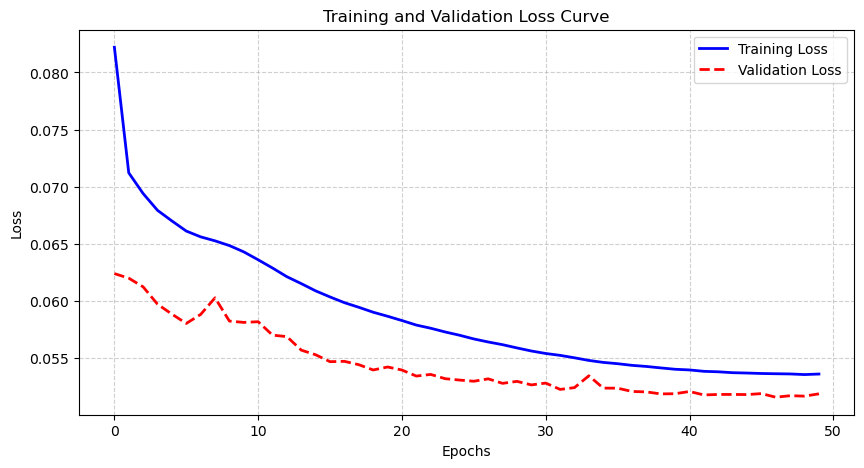

In [152]:
plt.figure(figsize=(10, 5))
plt.plot(loss_train, label='Training Loss', color='blue', linewidth=2)
plt.plot(loss_valid, label='Validation Loss', color='red', linestyle='--', linewidth=2)
plt.title('Training and Validation Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
# 如果你想保存图片，可以取消下面这行的注释
# plt.savefig('loss_curve.png', dpi=300)
plt.show()

In [153]:
loss_train = pd.DataFrame(loss_train)
loss_valid = pd.DataFrame(loss_valid)

loss = pd.concat([loss_train,loss_valid],axis=1)

In [154]:
loss.columns = ['train_loss','valid_loss']

In [155]:
torch.save(model.state_dict(), r'.\model_real2d_my17.pth')

In [156]:
# 1. 初始化模型并加载权重
model = AutoCoder(w1*w2, w1*w2).to(device)
model.load_state_dict(torch.load(r'.\model_real2d_my17.pth'))

# ===================== 核心优化：推理前彻底清理显存碎片 =====================
torch.cuda.empty_cache()  # 清理PyTorch未释放的显存，解决碎片
torch.cuda.ipc_collect()  # 清理进程间显存缓存，进一步减少碎片

# ===================== 推理核心：分批推理彻底解决爆显存 =====================
model.eval()  # 切换评估模式，关闭训练专属层（Dropout/BatchNorm）
batch_size_infer = 64  # 设置推理批次大小（和训练保持一致，也可尝试 128）
outputs = []           # 用于存放每一批推理出来的结果

with torch.no_grad():  # 禁用梯度计算，不保存计算图，省30%+显存   
    # 循环遍历整个 Pdata，每次只取一小批送给显卡计算
    for i in range(0, len(Pdata), batch_size_infer):
        # 取出一批数据，并将其移至显卡
        batch_data = Pdata[i : i+batch_size_infer].to(device)
        
        # 推理核心，这批算完后显存占用只是一小部分
        batch_output = model(batch_data)
        
        # 🚨最关键一步：立刻将算完的数据放回电脑内存 (CPU)，腾出显卡空间！
        outputs.append(batch_output.cpu())

# 在 CPU 内存上把所有批次的结果拼接成一个完整的大张量
output = torch.cat(outputs, dim=0)
output = output.numpy()

# ========== 新增：保存去噪结果为mat形式（反分块） ==========
# 重构去噪后的数据
n1 = Dn.shape[0]  # 对应MATLAB：n1 = size(Dn, 1)
n2 = Dn.shape[1]  # 对应MATLAB：n2 = size(Dn, 2)
D_denoised = patch2d_inv(output, n1, n2, w1, w2, s1, s2)
scipy.io.savemat(r"output_real2d_my17.mat", 
        {'D_denoised': D_denoised})  # 'D_denoised'是MAT文件里的变量名
        
print("推理完成！已成功导出为 output_real2d_my17.mat")

推理完成！已成功导出为 output_real2d_my17.mat


In [ ]:
#17
#criterion = HuberTVLoss( huber_delta=1.5, tv_weight=0.00050, huber_weight=0.90)

In [157]:
#16一般
#criterion = HuberTVLoss( huber_delta=1.5, tv_weight=0.00055, huber_weight=0.92)

In [158]:
#15 还行
#criterion = HuberTVLoss( huber_delta=1.5, tv_weight=0.00055, huber_weight=0.95)

In [159]:
#14 好用 很接近了 
#criterion = HuberTVLoss( huber_delta=1.5, tv_weight=0.00055, huber_weight=0.90)

In [160]:
#13 不好用 很差
#criterion = HuberTVLoss( huber_delta=1.5, tv_weight=0.00055, huber_weight=0.68)

In [161]:
#12 还可以
#criterion = HuberTVLoss( huber_delta=1.5, tv_weight=0.00055, huber_weight=0.80)

In [162]:
#11 decay=1e-5
#criterion = HuberTVLoss( huber_delta=1.5, tv_weight=0.0006, huber_weight=0.75)

In [163]:
#10 decay=1e-5
#criterion = HuberTVLoss( huber_delta=1.5, tv_weight=0.00075, huber_weight=0.75)

In [164]:
#8
#criterion = HuberTVLoss( huber_delta=1.5, tv_weight=0.0005, huber_weight=0.75)

In [165]:
#my6 7
#criterion = HuberTVLoss( huber_delta=1.5, tv_weight=0.00075,0.0001 huber_weight=0.75)

In [166]:
#my5
#criterion = HuberTVLoss( huber_delta=1.5, tv_weight=0.00075, huber_weight=0.8)

In [167]:
#31
#criterion = HuberTVLoss(w1=w1, w2=w2, huber_delta=1.5, tv_weight=0.000005 huber_weight=0.8)

In [168]:
print("推理完成！已成功导出为 output_real2d0027.mat")28 29 30 31
#criterion = HuberTVLoss(w1=w1, w2=w2, huber_delta=1.5, tv_weight=0.005,0.0005,0.0001,0.00005，0.000005 huber_weight=1.1)

SyntaxError: invalid syntax (1364666504.py, line 1)

In [ ]:
print("推理完成！已成功导出为 output_real2d0020-25.mat")
#一维的criterion = HuberTVLoss(huber_delta=1.5, tv_weight=从大到小, huber_weight=0.8)

In [ ]:
print("推理完成！已成功导出为 output_real2d0020.mat")
#criterion = HuberTVLoss(huber_delta=1.5, tv_weight=0.00001, huber_weight=0.8)

In [ ]:
print("推理完成！已成功导出为 output_real2d0018.mat")
#criterion = HuberTVLoss(w1=w1, w2=w2, huber_delta=1.5, tv_weight=0.00001, huber_weight=1.4)

In [ ]:
print("推理完成！已成功导出为 output_real2d0017.mat")
#criterion = HuberTVLoss(w1=w1, w2=w2, huber_delta=1.5, tv_weight=0.00005, huber_weight=1.5)

In [ ]:

print("推理完成！已成功导出为 output_real2d0016.mat")
#criterion = HuberTVLoss(w1=w1, w2=w2, huber_delta=1.5, tv_weight=0.00005, huber_weight=1.4)
#效果最好

In [ ]:

print("推理完成！已成功导出为 output_real2d0015.mat")
#criterion = HuberTVLoss(w1=w1, w2=w2, huber_delta=1.5, tv_weight=0.00005, huber_weight=1.3)
#效果最好

In [ ]:

print("推理完成！已成功导出为 output_real2d0014.mat")
#criterion = HuberTVLoss(w1=w1, w2=w2, huber_delta=1.5, tv_weight=0.00005, huber_weight=1.2)
#效果最好

In [ ]:

print("推理完成！已成功导出为 output_real2d0013.mat")
#criterion = HuberTVLoss(w1=w1, w2=w2, huber_delta=1.5, tv_weight=0.00005, huber_weight=1.1)
#效果最好

In [ ]:
print("推理完成！已成功导出为 output_real2d0012.mat")
#criterion = HuberTVLoss(w1=w1, w2=w2, huber_delta=1.5, tv_weight=0.00005, huber_weight=0.7)

In [ ]:
print("推理完成！已成功导出为 output_real2d0011.mat")
#criterion = HuberTVLoss(w1=w1, w2=w2, huber_delta=1.5, tv_weight=0.00005, huber_weight=0.8)

In [ ]:
#from pyseistr import gensyn
#data4,noisy4=gensyn(noise=True);[n1,n2]=data4.shape
#import matplotlib.pyplot as plt;
#plt.subplot(1,2,1);plt.imshow(data4,clim=[-0.2,0.2],aspect='auto');plt.xlabel('Trace');plt.ylabel('Time sample')
#plt.subplot(1,2,2);plt.imshow(noisy4,clim=[-0.2,0.2],aspect='auto');plt.xlabel('Trace')
#plt.show()
#
#X4=patch2d(data4,l1=16,l2=16,s1=8,s2=8)
##visualize the patches
#from pyseistr import cseis
#plt.imshow(X4,aspect='auto',cmap=cseis());plt.ylabel('Patch NO');plt.xlabel('Patch Pixel');plt.show()
#plt.figure(figsize=(8,8))
#for ii in range(64):
#	ax=plt.subplot(8,8,ii+1)
#	plt.imshow(X4[3200+ii,:].reshape(16,16,order='F'),cmap=cseis(),clim=(-0.5,0.5),aspect='auto')
#	plt.setp(ax.get_xticklabels(), visible=False);plt.setp(ax.get_yticklabels(), visible=False)
#plt.show()
##reconstruct
#import numpy as np
#print(X4.dtype)
#
#data41=patch2d_inv(X4,n1,n2,l1=16,l2=16,s1=8,s2=8)
#print('Error=',np.linalg.norm(data41.flatten()-data4.flatten()))
#
#plt.figure(figsize=(16,8))
#plt.imshow(np.concatenate([data41,data4,data41-data4],axis=1),aspect='auto')
#plt.show()

In [ ]:
model = AutoCoder(input_size=input_dim, output_size=input_dim)
total_params = sum(p.numel() for p in model.parameters())
print(f"总参数量: {total_params:,}")